# Logistic Regression - Simple English Explanation

## What is Logistic Regression?
**Logistic Regression** is used to predict **categories (Yes/No, True/False, Class A/Class B)**, not continuous numbers.

Think of it like a doctor making a diagnosis:
- **Input**: Features from medical tests
- **Output**: "Tumor is Malignant (0)" or "Tumor is Benign (1)"

## How Does It Work?
1. **It learns weights** for each feature (just like Linear Regression)
2. **It squeezes the answer** between 0 and 1 using a special curve called **Sigmoid**
3. **It predicts**: If answer > 0.5 → Class 1, Otherwise → Class 0

## Sigmoid Function - The Secret Ingredient
```
Sigmoid(x) = 1 / (1 + e^(-x))
```
This transforms any number into a probability between 0 and 1.

## Key Difference: Linear vs Logistic
| Aspect | Linear Regression | Logistic Regression |
|--------|------|--------|
| **Purpose** | Predict numbers (price, temperature) | Predict categories (Yes/No, Pass/Fail) |
| **Output** | Any number | Probability (0 to 1) |
| **Used For** | House prices, salary | Disease diagnosis, email spam |

## Example
Predicting **if a tumor is malignant or benign** using:
- Mean radius
- Mean texture
- Mean perimeter
- Mean area
- Mean smoothness
- Mean compactness
- And other medical features

**Prediction**: "87% chance this tumor is Benign" → Predict Class 1

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


## Step 2: Load and Explore Data
**What happens here?**
- Load the Breast Cancer dataset from sklearn
- Understand the shape and structure
- This is already a **binary classification problem**:
  - Class 0 = Malignant
  - Class 1 = Benign

In [4]:
# Load dataset
cancer_data = load_breast_cancer(as_frame=True)
X = cancer_data.data
y = cancer_data.target

X

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


## Step 3: Split Data into Training and Testing
**Why split?**
- **Training set (80%)**: Model learns from this
- **Testing set (20%)**: We test how well it learned (it hasn't seen this data before)

This prevents **cheating** - the model shouldn't see test data during training!

In [3]:
# Split data: 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✂️  Training set size: {X_train.shape[0]} samples")
print(f"✂️  Testing set size: {X_test.shape[0]} samples")

✂️  Training set size: 455 samples
✂️  Testing set size: 114 samples


## Step 4: Feature Scaling (Preprocessing)
**What is scaling?**
- StandardScaler transforms data so:
  - Mean = 0
  - Standard Deviation = 1
- **Why?** Logistic Regression performs better with scaled features
  - One feature won't dominate just because it has bigger numbers

In [6]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data
X_test_scaled = scaler.transform(X_test)        # Apply same scaling to test data

# Convert back to DataFrame for readability
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

X_train_scaled.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,-1.440753,-0.435319,-1.362085,-1.139118,0.780573,0.718921,2.823135,-0.119150,1.092662,2.458173,...,-1.232861,-0.476309,-1.247920,-0.973968,0.722894,1.186732,4.672828,0.932012,2.097242,1.886450
1,1.974096,1.733026,2.091672,1.851973,1.319843,3.426275,2.013112,2.665032,2.127004,1.558396,...,2.173314,1.311279,2.081617,2.137405,0.761928,3.265601,1.928621,2.698947,1.891161,2.497838
2,-1.399982,-1.249622,-1.345209,-1.109785,-1.332645,-0.307355,-0.365558,-0.696502,1.930333,0.954379,...,-1.295284,-1.040811,-1.245220,-0.999715,-1.438693,-0.548564,-0.644911,-0.970239,0.597602,0.057894
3,-0.981797,1.416222,-0.982587,-0.866944,0.059390,-0.596788,-0.820203,-0.845115,0.313264,0.074041,...,-0.829197,1.593530,-0.873572,-0.742947,0.796624,-0.729392,-0.774950,-0.809483,0.798928,-0.134497
4,-1.117700,-1.010259,-1.125002,-0.965942,1.269511,-0.439002,-0.983341,-0.930600,3.394436,0.950213,...,-1.085129,-1.334616,-1.117138,-0.896549,-0.174876,-0.995079,-1.209146,-1.354582,1.033544,-0.205732


## Step 5: Create and Train Logistic Regression Model
**What happens?**
1. Create a Logistic Regression model
2. Train it on scaled training data
3. The model learns **weights** for each feature

**Parameters:**
- `max_iter=1000`: Maximum iterations to find best weights
- `random_state=42`: For reproducibility (same results each time)

In [8]:
# Create and train model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train_scaled, y_train)

print(f"✅ Model trained successfully!")
print(f"\n🎯 Model Coefficients (Weights for each feature):")
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Weight': model.coef_[0],
    'Importance': np.abs(model.coef_[0])
}).sort_values('Importance', ascending=False)
coefficients

✅ Model trained successfully!

🎯 Model Coefficients (Weights for each feature):


,Feature,Weight,Importance
21,worst texture,-1.350606,1.350606
10,radius error,-1.268178,1.268178
28,worst symmetry,-1.208200,1.208200
7,mean concave points,-1.119804,1.119804
26,worst concavity,-0.943053,0.943053
13,area error,-0.907186,0.907186
20,worst radius,-0.879840,0.879840
23,worst area,-0.841846,0.841846
6,mean concavity,-0.801458,0.801458
27,worst concave points,-0.778217,0.778217


## Step 6: Make Predictions
**What happens?**
1. **Predict probabilities**: Get probability for each class (should sum to 1)
2. **Predict class**: If probability > 0.5 → Class 1, Otherwise → Class 0

In [9]:
# Make predictions on test set
y_pred = model.predict(X_test_scaled)  # Predicted classes (0 or 1)
y_pred_proba = model.predict_proba(X_test_scaled)  # Predicted probabilities

print(f"🎯 Predictions (first 20):")
print(y_pred[:20])
print(f"\n🎯 Prediction Probabilities (first 10):")
print("Class 0      Class 1")
for i in range(10):
    print(f"{y_pred_proba[i][0]:.4f}    {y_pred_proba[i][1]:.4f}")
print(f"\n💡 If Class 1 probability > 0.5, we predict Class 1")

🎯 Predictions (first 20):
[1 0 0 1 1 0 0 0 1 1 1 0 1 0 1 0 1 1 1 0]

🎯 Prediction Probabilities (first 10):
Class 0      Class 1
0.1136    0.8864
1.0000    0.0000
0.9969    0.0031
0.0005    0.9995
0.0001    0.9999
1.0000    0.0000
1.0000    0.0000
0.9651    0.0349
0.3793    0.6207
0.0008    0.9992

💡 If Class 1 probability > 0.5, we predict Class 1


## Step 7: Evaluate Model - Important Scores Explained

### 🎯 Classification Metrics (Easy English)

**Accuracy**: "Out of all predictions, how many were correct?"
- Formula: (Correct Predictions) / (Total Predictions)
- Range: 0 to 1 (0% to 100%)
- Good when: Classes are balanced

**Precision**: "When we predict Class 1 (positive), how often are we correct?"
- Formula: (True Positives) / (True Positives + False Positives)
- Meaning: Of all **positive predictions**, how many were actually positive?
- Use when: False positives are expensive (e.g., cancer diagnosis)

**Recall (Sensitivity)**: "Of all actual Class 1 samples, how many did we find?"
- Formula: (True Positives) / (True Positives + False Negatives)
- Meaning: Did we catch all the true positives?
- Use when: False negatives are expensive (e.g., disease detection)

**F1-Score**: "The balance between Precision and Recall"
- Formula: 2 × (Precision × Recall) / (Precision + Recall)
- Use when: You need both precision and recall to be good

In [10]:
# Calculate scores
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("="*50)
print("🎯 MODEL EVALUATION SCORES")
print("="*50)
print(f"✅ Accuracy:  {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   → Out of all predictions, {accuracy*100:.2f}% were correct")
print(f"\n🎯 Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   → When we predict 'Benign', we're correct {precision*100:.2f}% of the time")
print(f"\n🎯 Recall:    {recall:.4f} ({recall*100:.2f}%)")
print(f"   → We successfully identified {recall*100:.2f}% of actual benign cases")
print(f"\n🎯 F1-Score:  {f1:.4f}")
print(f"   → Balance between precision and recall")
print("="*50)

🎯 MODEL EVALUATION SCORES
✅ Accuracy:  0.9737 (97.37%)
   → Out of all predictions, 97.37% were correct

🎯 Precision: 0.9722 (97.22%)
   → When we predict 'Benign', we're correct 97.22% of the time

🎯 Recall:    0.9859 (98.59%)
   → We successfully identified 98.59% of actual benign cases

🎯 F1-Score:  0.9790
   → Balance between precision and recall


## Step 8: Confusion Matrix
**The Confusion Matrix shows:**
```
                       Predicted: Malignant    Predicted: Benign
Actually Malignant     [True Neg]              [False Pos]
Actually Benign        [False Neg]             [True Pos]
```
- **True Negative (TN)**: Predicted malignant, actually malignant ✅
- **False Positive (FP)**: Predicted benign, actually malignant ❌
- **False Negative (FN)**: Predicted malignant, actually benign ❌
- **True Positive (TP)**: Predicted benign, actually benign ✅

In [11]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\n📊 Confusion Matrix:")
print(cm)
print(f"\n📊 True Negatives (TN):  {cm[0,0]}  (Correctly predicted 'Malignant')")
print(f"📊 False Positives (FP): {cm[0,1]}  (Incorrectly predicted 'Benign')")
print(f"📊 False Negatives (FN): {cm[1,0]}  (Incorrectly predicted 'Malignant')")
print(f"📊 True Positives (TP):  {cm[1,1]}  (Correctly predicted 'Benign')")


📊 Confusion Matrix:
[[41  2]
 [ 1 70]]

📊 True Negatives (TN):  41  (Correctly predicted 'Malignant')
📊 False Positives (FP): 2  (Incorrectly predicted 'Benign')
📊 False Negatives (FN): 1  (Incorrectly predicted 'Malignant')
📊 True Positives (TP):  70  (Correctly predicted 'Benign')


## Step 9: Visualize Results
**Graphs we'll create:**
1. **Confusion Matrix Heatmap**: See where predictions are wrong
2. **Classification Metrics Bar Chart**: Compare accuracy, precision, recall, F1
3. **Prediction Probability Distribution**: How confident are predictions?

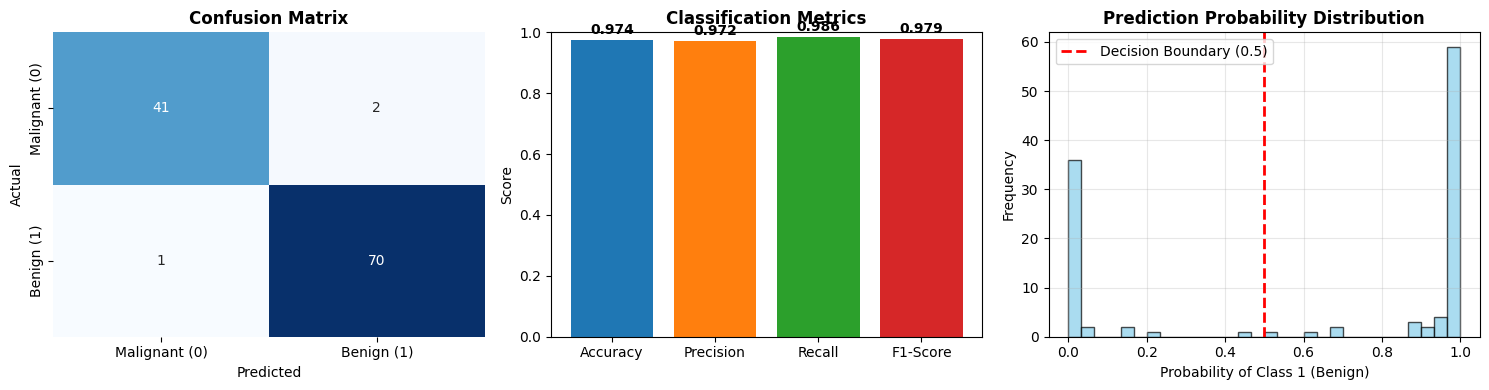

✅ Visualizations created!


In [12]:
# Create figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Confusion Matrix Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')
axes[0].set_xticklabels(['Malignant (0)', 'Benign (1)'])
axes[0].set_yticklabels(['Malignant (0)', 'Benign (1)'])

# 2. Classification Metrics Bar Chart
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
scores = [accuracy, precision, recall, f1]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
axes[1].bar(metrics, scores, color=colors)
axes[1].set_title('Classification Metrics', fontsize=12, fontweight='bold')
axes[1].set_ylim([0, 1])
axes[1].set_ylabel('Score')
for i, (metric, score) in enumerate(zip(metrics, scores)):
    axes[1].text(i, score + 0.02, f'{score:.3f}', ha='center', fontweight='bold')

# 3. Prediction Probability Distribution
axes[2].hist(y_pred_proba[:, 1], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
axes[2].axvline(0.5, color='red', linestyle='--', linewidth=2, label='Decision Boundary (0.5)')
axes[2].set_title('Prediction Probability Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Probability of Class 1 (Benign)')
axes[2].set_ylabel('Frequency')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Visualizations created!")

## Step 10: Classification Report
**Complete breakdown of model performance for each class**

In [13]:
# Classification Report
print("\n📋 CLASSIFICATION REPORT:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['Malignant (0)', 'Benign (1)']))
print("="*60)


📋 CLASSIFICATION REPORT:
               precision    recall  f1-score   support

Malignant (0)       0.98      0.95      0.96        43
   Benign (1)       0.97      0.99      0.98        71

     accuracy                           0.97       114
    macro avg       0.97      0.97      0.97       114
 weighted avg       0.97      0.97      0.97       114



## Step 11: Make Sample Predictions
**Predicted on new, unseen data**

In [14]:
# Make predictions on first 5 test samples
print("\n🎯 Sample Predictions (First 5 Test Samples):")
print("="*80)
for i in range(5):
    actual = "Benign" if y_test.iloc[i] == 1 else "Malignant"
    predicted = "Benign" if y_pred[i] == 1 else "Malignant"
    prob_class_1 = y_pred_proba[i][1]
    confidence = "✅ Correct" if y_pred[i] == y_test.iloc[i] else "❌ Wrong"
    
    print(f"\nSample {i+1}:")
    print(f"  Actual: {actual}")
    print(f"  Predicted: {predicted}")
    print(f"  Confidence (Benign): {prob_class_1*100:.2f}%")
    print(f"  Status: {confidence}")
print("="*80)


🎯 Sample Predictions (First 5 Test Samples):

Sample 1:
  Actual: Benign
  Predicted: Benign
  Confidence (Benign): 88.64%
  Status: ✅ Correct

Sample 2:
  Actual: Malignant
  Predicted: Malignant
  Confidence (Benign): 0.00%
  Status: ✅ Correct

Sample 3:
  Actual: Malignant
  Predicted: Malignant
  Confidence (Benign): 0.31%
  Status: ✅ Correct

Sample 4:
  Actual: Benign
  Predicted: Benign
  Confidence (Benign): 99.95%
  Status: ✅ Correct

Sample 5:
  Actual: Benign
  Predicted: Benign
  Confidence (Benign): 99.99%
  Status: ✅ Correct
